In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Environment ready!")
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

Environment ready!
Pandas: 3.0.6
NumPy: 2.5.3


In [3]:
from pathlib import Path

columns = (
    ["unit_id", "cycle", "setting_1", "setting_2", "setting_3"]
    + [f"sensor_{i}" for i in range(1, 22)]
)

train_path = Path("../data/raw/train_FD001.txt")

train = pd.read_csv(
    train_path,
    sep=r"\s+",
    header=None,
    names=columns
)

print("Dataset shape:", train.shape)
train.head()

Dataset shape: (20631, 26)


,unit_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [4]:
print("Shape:", train.shape)
print("\nNumber of engines:", train["unit_id"].nunique())
print("\nCycles per engine:")
print(train.groupby("unit_id")["cycle"].max().describe())

print("\nMissing values:")
print(train.isna().sum().sum())

print("\nColumns:")
print(train.columns.tolist())

Shape: (20631, 26)

Number of engines: 100

Cycles per engine:
count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64

Missing values:
0

Columns:
['unit_id', 'cycle', 'setting_1', 'setting_2', 'setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


In [5]:
print("Total missing values:", train.isna().sum().sum())

print("\nColumn names:")
for i, col in enumerate(train.columns):
    print(i, "→", col)

Total missing values: 0

Column names:
0 → unit_id
1 → cycle
2 → setting_1
3 → setting_2
4 → setting_3
5 → sensor_1
6 → sensor_2
7 → sensor_3
8 → sensor_4
9 → sensor_5
10 → sensor_6
11 → sensor_7
12 → sensor_8
13 → sensor_9
14 → sensor_10
15 → sensor_11
16 → sensor_12
17 → sensor_13
18 → sensor_14
19 → sensor_15
20 → sensor_16
21 → sensor_17
22 → sensor_18
23 → sensor_19
24 → sensor_20
25 → sensor_21


In [6]:
sensor_cols = [f"sensor_{i}" for i in range(1, 22)]

sensor_summary = pd.DataFrame({
    "mean": train[sensor_cols].mean(),
    "std": train[sensor_cols].std(),
    "unique_values": train[sensor_cols].nunique(),
    "min": train[sensor_cols].min(),
    "max": train[sensor_cols].max()
})

sensor_summary.sort_values("std")

,mean,std,unique_values,min,max
sensor_1,518.670000,0.000000e+00,1,518.6700,518.6700
sensor_10,1.300000,0.000000e+00,1,1.3000,1.3000
sensor_19,100.000000,0.000000e+00,1,100.0000,100.0000
sensor_18,2388.000000,0.000000e+00,1,2388.0000,2388.0000
sensor_16,0.030000,3.469531e-18,1,0.0300,0.0300
sensor_5,14.620000,5.329200e-15,1,14.6200,14.6200
sensor_6,21.609803,1.388985e-03,2,21.6000,21.6100
sensor_15,8.442146,3.750504e-02,1918,8.3249,8.5848
sensor_8,2388.096652,7.098548e-02,53,2387.9000,2388.5600
sensor_13,2388.096152,7.191892e-02,56,2387.8800,2388.5600


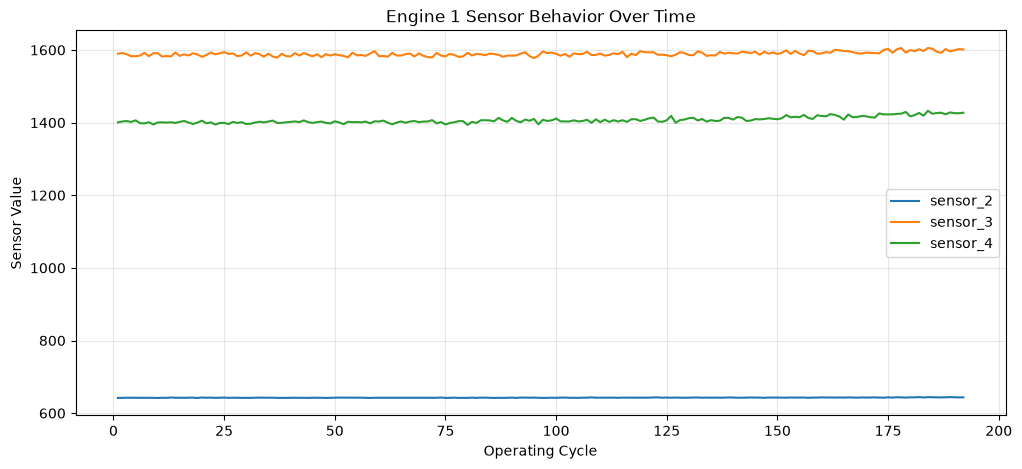

In [7]:
engine_1 = train[train["unit_id"] == 1]

plt.figure(figsize=(12, 5))

for sensor in ["sensor_2", "sensor_3", "sensor_4"]:
    plt.plot(
        engine_1["cycle"],
        engine_1[sensor],
        label=sensor
    )

plt.xlabel("Operating Cycle")
plt.ylabel("Sensor Value")
plt.title("Engine 1 Sensor Behavior Over Time")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [8]:
# Calculate the final cycle reached by each engine
max_cycle = train.groupby("unit_id")["cycle"].transform("max")

# Remaining Useful Life
train["RUL"] = max_cycle - train["cycle"]

print(train[["unit_id", "cycle", "RUL"]].head(10))

   unit_id  cycle  RUL
0        1      1  191
1        1      2  190
2        1      3  189
3        1      4  188
4        1      5  187
5        1      6  186
6        1      7  185
7        1      8  184
8        1      9  183
9        1     10  182


In [9]:
print("RUL statistics:")
print(train["RUL"].describe())

print("\nRUL range:")
print(train["RUL"].min(), "to", train["RUL"].max())

RUL statistics:
count    20631.000000
mean       107.807862
std         68.880990
min          0.000000
25%         51.000000
50%        103.000000
75%        155.000000
max        361.000000
Name: RUL, dtype: float64

RUL range:
0 to 361


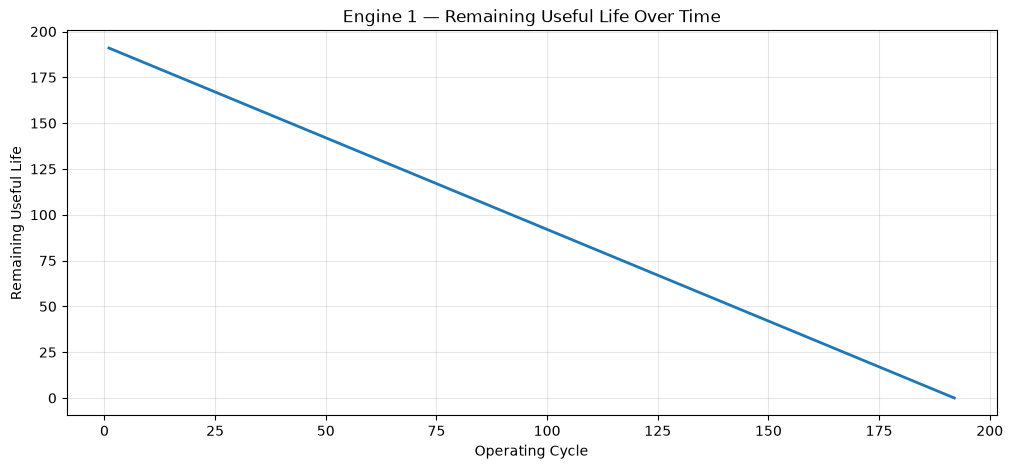

In [10]:
engine_1 = train[train["unit_id"] == 1]

plt.figure(figsize=(12, 5))

plt.plot(
    engine_1["cycle"],
    engine_1["RUL"],
    linewidth=2
)

plt.xlabel("Operating Cycle")
plt.ylabel("Remaining Useful Life")
plt.title("Engine 1 — Remaining Useful Life Over Time")
plt.grid(alpha=0.3)
plt.show()

In [11]:
# Correlation between sensor measurements and RUL
sensor_rul_corr = (
    train[sensor_cols + ["RUL"]]
    .corr()["RUL"]
    .drop("RUL")
    .sort_values()
)

print("Sensor correlation with RUL:")
print(sensor_rul_corr)

Sensor correlation with RUL:
sensor_11   -0.696228
sensor_4    -0.678948
sensor_15   -0.642667
sensor_2    -0.606484
sensor_17   -0.606154
sensor_3    -0.584520
sensor_8    -0.563968
sensor_13   -0.562569
sensor_9    -0.390102
sensor_14   -0.306769
sensor_6    -0.128348
sensor_20    0.629428
sensor_21    0.635662
sensor_7     0.657223
sensor_12    0.671983
sensor_1          NaN
sensor_5          NaN
sensor_10         NaN
sensor_16         NaN
sensor_18         NaN
sensor_19         NaN
Name: RUL, dtype: float64


In [12]:
sensor_rul_corr = (
    train[sensor_cols + ["RUL"]]
    .corr()["RUL"]
    .drop("RUL")
    .sort_values()
)

print("Sensor correlation with RUL:")
print(sensor_rul_corr)

Sensor correlation with RUL:
sensor_11   -0.696228
sensor_4    -0.678948
sensor_15   -0.642667
sensor_2    -0.606484
sensor_17   -0.606154
sensor_3    -0.584520
sensor_8    -0.563968
sensor_13   -0.562569
sensor_9    -0.390102
sensor_14   -0.306769
sensor_6    -0.128348
sensor_20    0.629428
sensor_21    0.635662
sensor_7     0.657223
sensor_12    0.671983
sensor_1          NaN
sensor_5          NaN
sensor_10         NaN
sensor_16         NaN
sensor_18         NaN
sensor_19         NaN
Name: RUL, dtype: float64


In [13]:
top_sensors = sensor_rul_corr.abs().sort_values(ascending=False).head(5)

print("Top 5 sensors by absolute correlation with RUL:")
print(top_sensors)

Top 5 sensors by absolute correlation with RUL:
sensor_11    0.696228
sensor_4     0.678948
sensor_12    0.671983
sensor_7     0.657223
sensor_15    0.642667
Name: RUL, dtype: float64


In [14]:
top_sensors = sensor_rul_corr.abs().sort_values(ascending=False).head(4).index

print("Top 4 sensors:")
print(top_sensors.tolist())

Top 4 sensors:
['sensor_11', 'sensor_4', 'sensor_12', 'sensor_7']


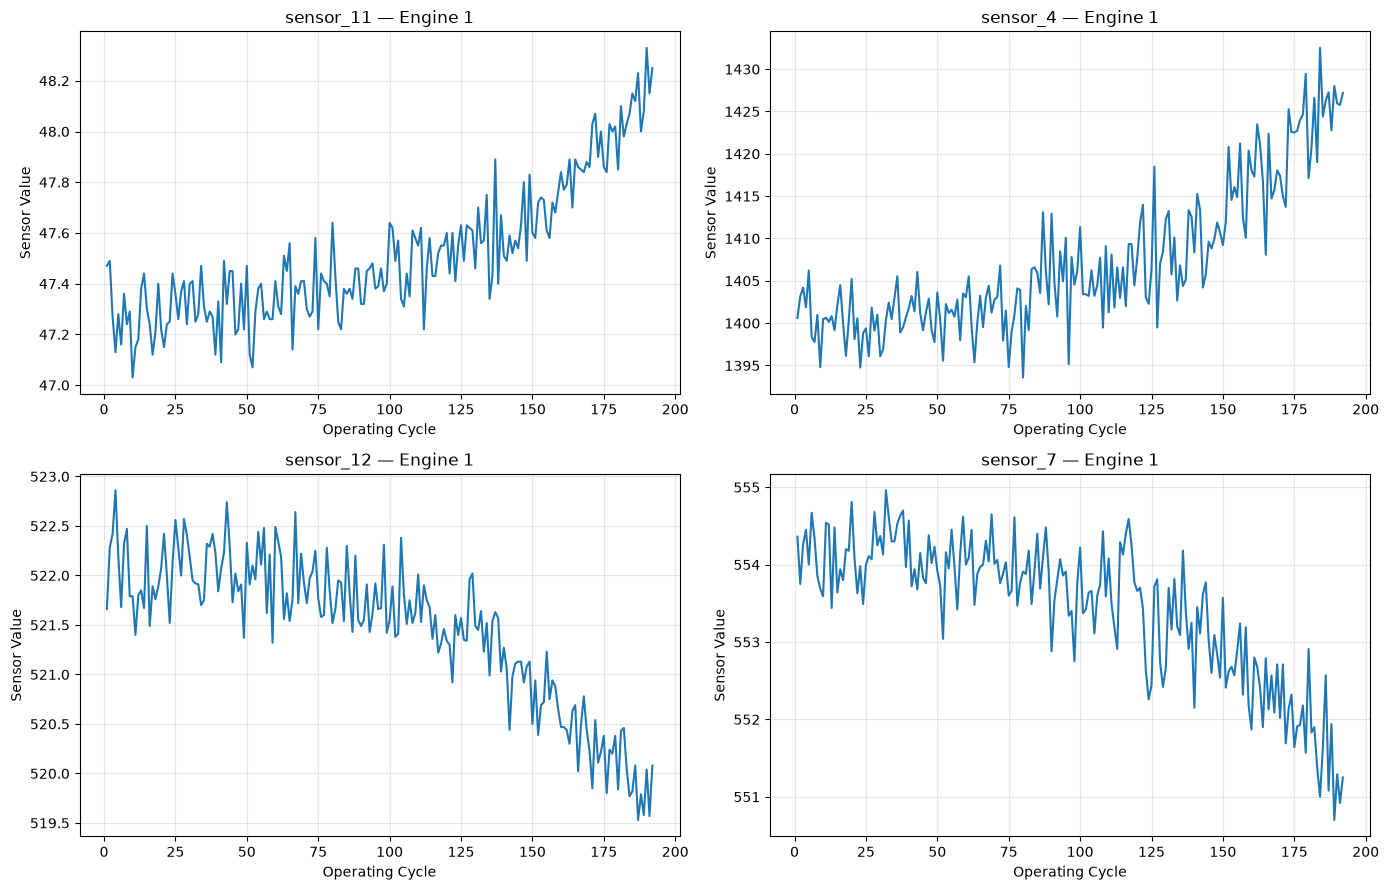

In [15]:
engine_1 = train[train["unit_id"] == 1]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, sensor in zip(axes.flatten(), top_sensors):
    ax.plot(engine_1["cycle"], engine_1[sensor])
    ax.set_title(f"{sensor} — Engine 1")
    ax.set_xlabel("Operating Cycle")
    ax.set_ylabel("Sensor Value")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

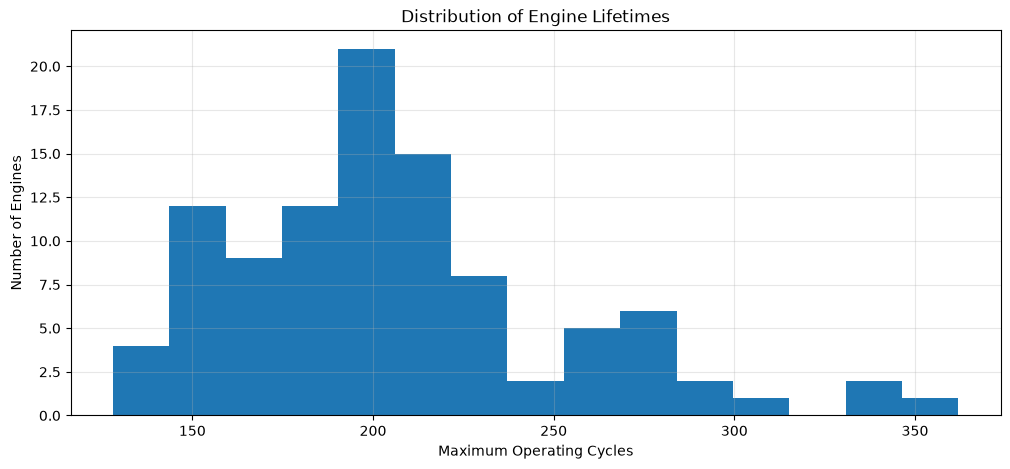

In [16]:
engine_lengths = (
    train.groupby("unit_id")["cycle"]
    .max()
    .sort_values()
)

plt.figure(figsize=(12, 5))
plt.hist(engine_lengths, bins=15)
plt.xlabel("Maximum Operating Cycles")
plt.ylabel("Number of Engines")
plt.title("Distribution of Engine Lifetimes")
plt.grid(alpha=0.3)
plt.show()

In [18]:
# Work on a copy so the original dataset remains untouched
features = train.copy()

# Sensors selected for initial temporal feature engineering
selected_sensors = top_sensors.tolist()

print("Selected sensors:")
print(selected_sensors)

Selected sensors:
['sensor_11', 'sensor_4', 'sensor_12', 'sensor_7']


In [19]:
# Sort by engine and operating cycle
features = features.sort_values(["unit_id", "cycle"]).reset_index(drop=True)

# Create rolling statistics for each engine
for sensor in selected_sensors:
    features[f"{sensor}_rolling_mean"] = (
        features.groupby("unit_id")[sensor]
        .transform(lambda x: x.rolling(window=10, min_periods=1).mean())
    )

    features[f"{sensor}_rolling_std"] = (
        features.groupby("unit_id")[sensor]
        .transform(lambda x: x.rolling(window=10, min_periods=2).std())
    )

print("New feature matrix shape:", features.shape)

New feature matrix shape: (20631, 35)
